In [91]:
import pandas as pd
import numpy as np
import sklearn as sk
import matplotlib.pyplot as plt 
import seaborn as sns

In [92]:
# Reading dataset
marketingdataset = pd.read_csv("Assignment3-Marketing-Dataset.csv")
marketingdataset

,row ID,age,job,marital,education,default,housing,loan,contact,month,...,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,state,subscribed
0,Row0,56,housemaid,married,basic.4y,no,no,no,telephone,may,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191,VIC,0
1,Row1,56,services,married,high.school,no,no,yes,telephone,may,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191,NT,0
2,Row2,45,services,married,basic.9y,unknown,no,no,telephone,may,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191,TAS,0
3,Row3,59,admin.,married,professional.course,no,no,no,telephone,may,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191,NSW,0
4,Row4,41,blue-collar,married,unknown,unknown,no,no,telephone,may,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191,ACT,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26355,Row26355,29,unemployed,single,basic.4y,no,yes,no,cellular,nov,...,9,1,success,-1.1,94.767,-50.8,1.028,4963.6,SA,0
26356,Row26356,46,blue-collar,married,professional.course,no,no,no,cellular,nov,...,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,TAS,0
26357,Row26357,56,retired,married,university.degree,no,yes,no,cellular,nov,...,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,VIC,0
26358,Row26358,44,technician,married,professional.course,no,no,no,cellular,nov,...,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,WA,1


In [93]:
# Total number of columns
print(len(marketingdataset.columns))

23


# Data preprocessing 

In [94]:
#Check missing values in each columns 
missing_values = marketingdataset.isin(['?', 'unknown']).sum()
print(missing_values)

row ID               0
age                  0
job                212
marital             51
education         1080
default           5551
housing            647
loan               647
contact              0
month                0
day_of_week          0
duration             0
campaign             0
pdays             1273
previous             0
poutcome             0
emp.var.rate       821
cons.price.idx     296
cons.conf.idx      248
euribor3m          547
nr.employed        267
state                0
subscribed           0
dtype: int64


In [95]:
# Find the percentage of missing values
total_rows = len(marketingdataset)
missing_percent = ((missing_values/total_rows) * 100).round(2)
# Print a summary table 
missing_summary = pd.DataFrame(
    {'Attribute ' : missing_percent.index, 
    '% of row with missing data': missing_percent.values
    }
)
print(missing_summary)

        Attribute   % of row with missing data
0           row ID                        0.00
1              age                        0.00
2              job                        0.80
3          marital                        0.19
4        education                        4.10
5          default                       21.06
6          housing                        2.45
7             loan                        2.45
8          contact                        0.00
9            month                        0.00
10     day_of_week                        0.00
11        duration                        0.00
12        campaign                        0.00
13           pdays                        4.83
14        previous                        0.00
15        poutcome                        0.00
16    emp.var.rate                        3.11
17  cons.price.idx                        1.12
18   cons.conf.idx                        0.94
19       euribor3m                        2.08
20     nr.emp

## Clean data
From the table, all attributes have less than 5% missing, except "default" which has over 20% missing. 
Therefore, it would be safe to impute these columns and drop "default" columns.

In [96]:
# print(marketingdataset.dtypes)

In [97]:
# View different sources to clean data (rerfer to References)
# Drop all missing values in "default"  
# Create a list to store row without missing value
keepRow  = []  
#Iterate through row 
for index, row in marketingdataset.iterrows():
    if row['default'] not in ['?', 'unknown']:
        keepRow.append(index)
# Filter the DataFrame by selecting only the rows to keep
marketingdataset = marketingdataset.loc[keepRow]

# Impute other attributes 
for column in marketingdataset:
    # Replace missing values with pandas NaN null then fill
    marketingdataset[column] = marketingdataset[column].replace(['?', 'unknown'], pd.NA)
    # Check if there are missing values null
    if marketingdataset[column].isnull().sum() > 0:
        if marketingdataset[column].dtype == 'object':
            fill_mode = marketingdataset[column].mode()[0] # incase many modes, get the first one
            marketingdataset[column].fillna(fill_mode, inplace=True)
        else:
            # Numeric column → impute with mean
            fill_mean = marketingdataset[column].mean()
            marketingdataset[column].fillna(fill_mean, inplace=True)


/var/folders/vj/3d155nx56n3g1y64vxb08pcw0000gn/T/ipykernel_76572/2934297353.py:20: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  marketingdataset[column].fillna(fill_mode, inplace=True)


In [98]:
marketingdataset

,row ID,age,job,marital,education,default,housing,loan,contact,month,...,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,state,subscribed
0,Row0,56,housemaid,married,basic.4y,no,no,no,telephone,may,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191,VIC,0
1,Row1,56,services,married,high.school,no,no,yes,telephone,may,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191,NT,0
3,Row3,59,admin.,married,professional.course,no,no,no,telephone,may,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191,NSW,0
5,Row5,24,technician,single,professional.course,no,yes,no,telephone,may,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191,NT,0
6,Row6,25,services,single,high.school,no,yes,no,telephone,may,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191,SA,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26355,Row26355,29,unemployed,single,basic.4y,no,yes,no,cellular,nov,...,9,1,success,-1.1,94.767,-50.8,1.028,4963.6,SA,0
26356,Row26356,46,blue-collar,married,professional.course,no,no,no,cellular,nov,...,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,TAS,0
26357,Row26357,56,retired,married,university.degree,no,yes,no,cellular,nov,...,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,VIC,0
26358,Row26358,44,technician,married,professional.course,no,no,no,cellular,nov,...,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,WA,1


In [99]:
# Check again if there are any missing values
any_missing_values = marketingdataset.isin(['?', 'unknown']).sum()
any_missing_values

row ID            0
age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
state             0
subscribed        0
dtype: int64

In [100]:
# Check unique values
for col in marketingdataset.columns:
    print(f"Column: {col}")
    print(marketingdataset[col].unique())

Column: row ID
['Row0' 'Row1' 'Row3' ... 'Row26357' 'Row26358' 'Row26359']
Column: age
[56 59 24 25 29 57 35 55 37 46 49 54 34 52 58 32 38 40 45 39 60 51 33 44
 31 36 41 50 53 43 28 48 30 42 47 27 23 26 20 22 61 21 70 66 76 73 88 95
 19 75 63 65 71 69 67 64 68 78 62 85 79 18 77 81 83 74 17 82 72 80 87 91
 86 94 84 92 89]
Column: job
['housemaid' 'services' 'admin.' 'technician' 'blue-collar' 'retired'
 'management' 'entrepreneur' 'student' 'self-employed' 'unemployed']
Column: marital
['married' 'single' 'divorced']
Column: education
['basic.4y' 'high.school' 'professional.course' 'basic.6y'
 'university.degree' 'basic.9y' 'illiterate']
Column: default
['no' 'yes']
Column: housing
['no' 'yes']
Column: loan
['no' 'yes']
Column: contact
['telephone' 'cellular']
Column: month
['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'mar' 'apr' 'sep']
Column: day_of_week
['mon' 'tue' 'wed' 'thu' 'fri']
Column: duration
[ 261  307  139 ... 1394  759 1868]
Column: campaign
[ 1  2  3  4  5  6  7  9  8 11 1

In [101]:
marketingdataset.columns

Index(['row ID', 'age', 'job', 'marital', 'education', 'default', 'housing',
       'loan', 'contact', 'month', 'day_of_week', 'duration', 'campaign',
       'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'state', 'subscribed'],
      dtype='object')

# Normalization

In [102]:
from sklearn.preprocessing import MinMaxScaler

# Scaler
min_max_scaler = MinMaxScaler()

# Chosen columns to normalise
col_to_normalise = [    'age', 'duration','emp.var.rate','cons.price.idx', 'cons.conf.idx', 
    'euribor3m', 'nr.employed', 'pdays']

# Normalize the columns
for col in col_to_normalise:
    marketingdataset[col] = min_max_scaler.fit_transform(marketingdataset[col].values.reshape(-1, 1))


# Data transformation
- Encode job, marital, education, contact, month, day_of_week, campaign, poutcome, state
- Encode binary columns: deafult, housing, loan, previous 

In [103]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

# Initialize the LabelEncoder
label_encoder = LabelEncoder()
label_encode_columns = ['job', 'marital', 'education', 'campaign', 'month', 'day_of_week', 'state', 'row ID']

# Apply LabelEncoder to each column
for column in label_encode_columns:
    marketingdataset[column] = label_encoder.fit_transform(marketingdataset[column].values.reshape(-1, 1))

# Initialize the OneHoteEncoder
onehot_encoder = OneHotEncoder(dtype=int, sparse_output=False)
onehot_encode_columns = ['contact', 'default', 'housing', 'loan', 'poutcome', 'previous']
for col in onehot_encode_columns:
        marketingdataset[col] = onehot_encoder.fit_transform(marketingdataset[col].values.reshape(-1, 1))

/opt/anaconda3/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/anaconda3/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/anaconda3/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/anaconda3/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of 

In [104]:
#marketingdataset

# Linear/rank correlation 

In [105]:
# marketingdataset.dtypes

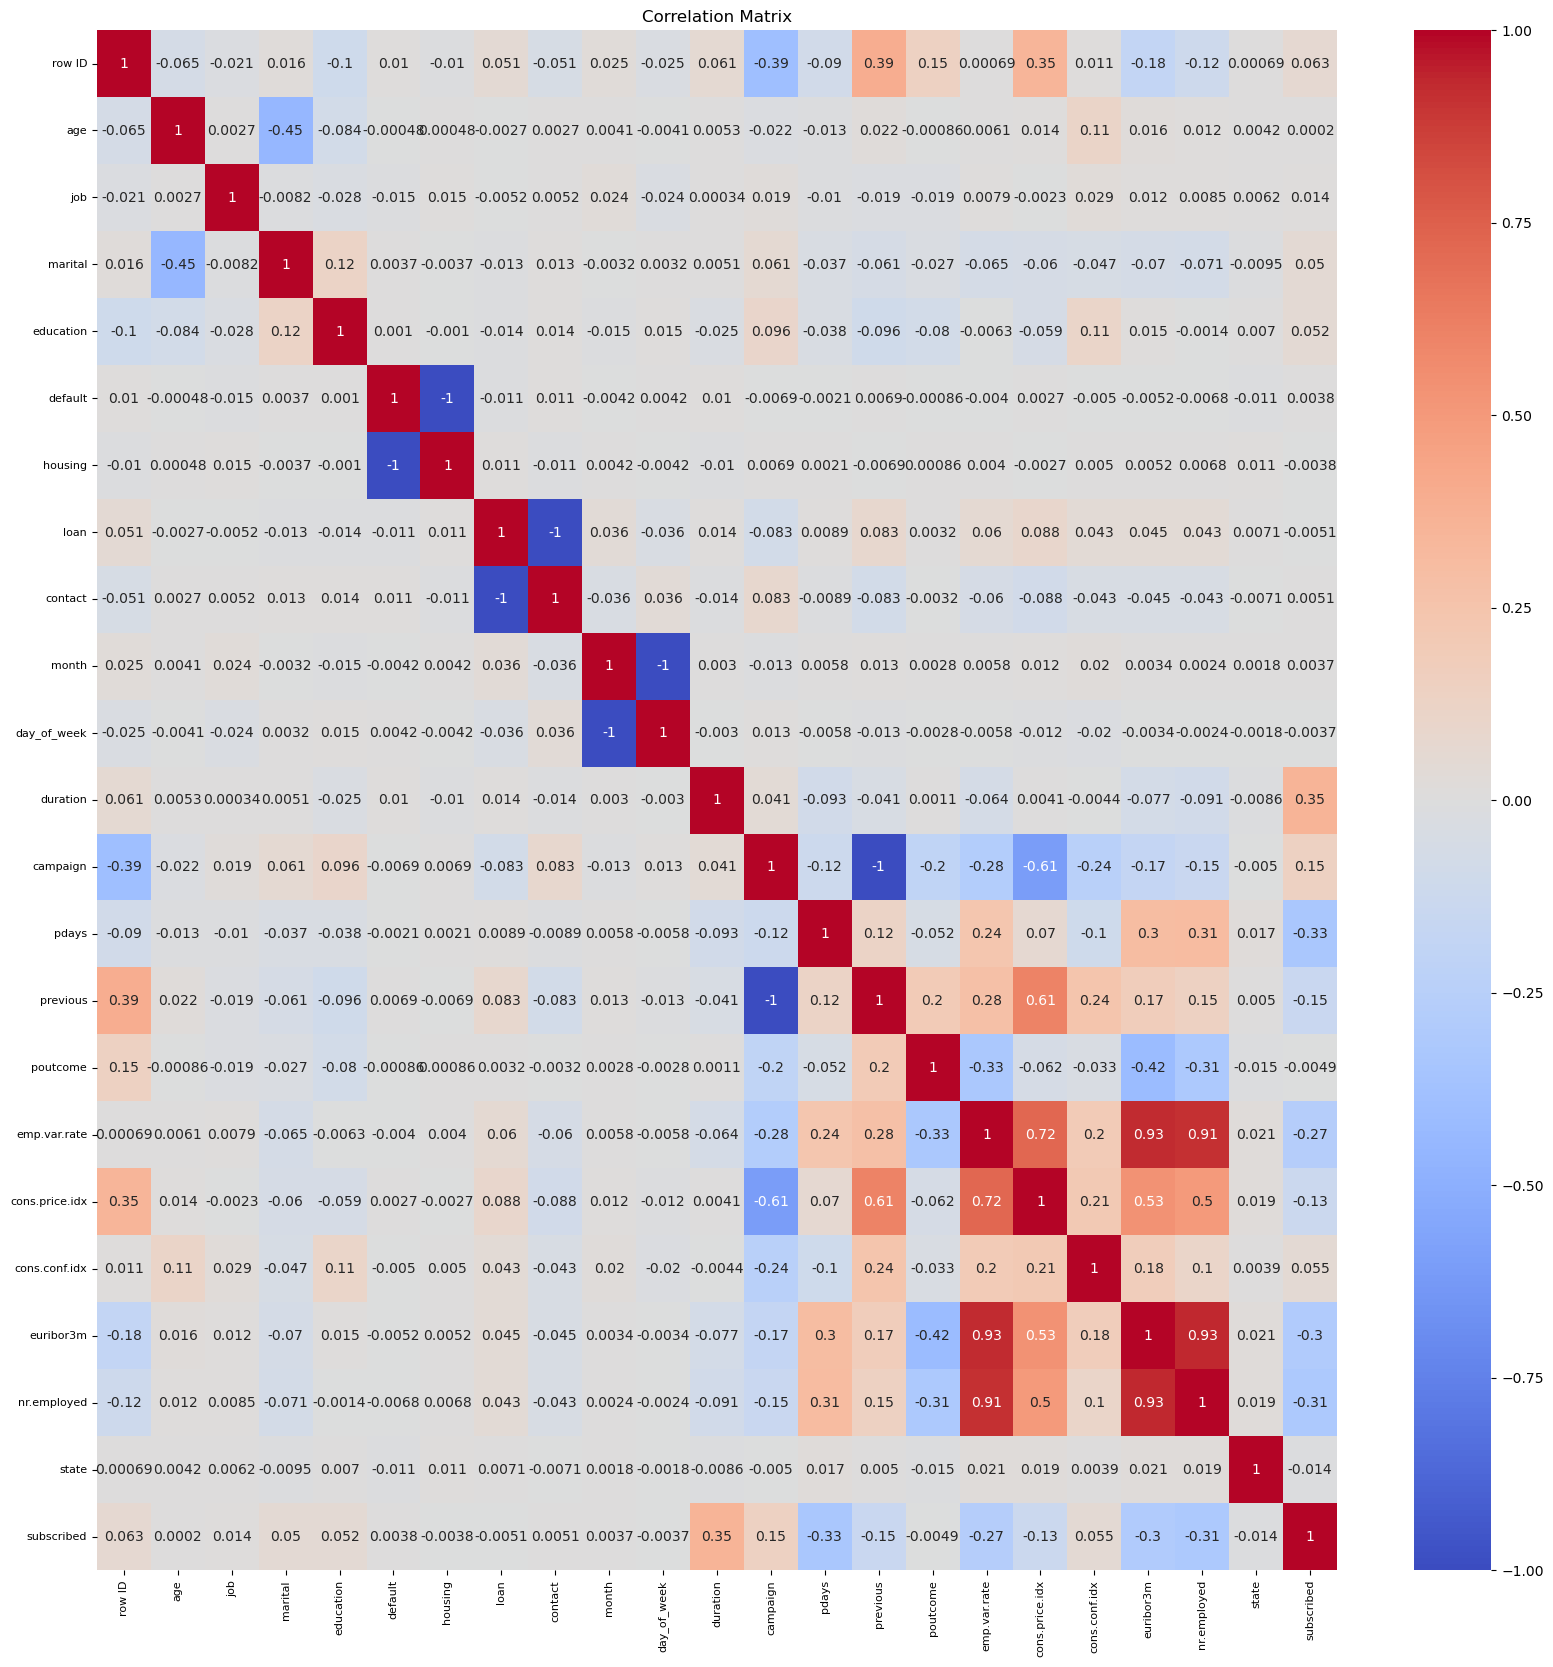

In [106]:
# Select relevant numerical columns
numeric_cols = marketingdataset.select_dtypes(include = 'number')
# Compute Spearman correlation matrix
spearman_corr = numeric_cols.corr(method='spearman')

# Plot heatmap
plt.figure(figsize=(20,20))
sns.heatmap(spearman_corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.show()


# Feature selection
- Based on the correlation matrix, we can select strong predictor instead of weak prediction

In [107]:
sub_marketingdataset = marketingdataset[['row ID', 'duration', 'campaign', 'nr.employed', 'euribor3m', 'emp.var.rate', 'cons.price.idx','previous', 'marital', 'education' ,'subscribed']]

In [108]:
sub_marketingdataset

,row ID,duration,campaign,nr.employed,euribor3m,emp.var.rate,cons.price.idx,previous,marital,education,subscribed
0,0,0.053070,0,0.859735,0.957379,0.937500,0.698753,1,1,0,0
1,1,0.062424,0,0.859735,0.957379,0.937500,0.698753,1,1,3,0
3,15332,0.028264,0,0.859735,0.957379,0.937500,0.698753,1,1,5,0
5,16847,0.077267,0,0.859735,0.957379,0.937500,0.698753,1,2,5,0
6,17591,0.010167,0,0.859735,0.957379,0.937500,0.698753,1,2,3,0
...,...,...,...,...,...,...,...,...,...,...,...
26355,15053,0.022773,0,0.000000,0.089322,0.479167,1.000000,0,2,0,0
26356,15054,0.077877,0,0.000000,0.089322,0.479167,1.000000,1,1,5,0
26357,15055,0.038430,1,0.000000,0.089322,0.479167,1.000000,1,1,6,0
26358,15056,0.089874,0,0.000000,0.089322,0.479167,1.000000,1,1,5,1


# Building model
 - Subscribed will be the target columns 
 - To estimate the number of people subscribe to the campaign 

In [109]:
from sklearn.model_selection import train_test_split
from sklearn.utils import resample

# Select X-columns and Y-target
Y = sub_marketingdataset['subscribed']
X = sub_marketingdataset.drop(columns=['subscribed', 'row ID'])

# Train-test split
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Downsampling (MrMey, 2019) to address class imbalance
train = pd.concat([x_train, y_train], axis=1)
minority = train[train['subscribed'] == 1]
majority = train[train['subscribed'] == 0]
minority_sampled = resample(minority, replace=True, n_samples=len(majority), random_state=42) #using resample 
sampled = pd.concat([majority, minority_sampled])
# Update 
x_train = sampled.drop('subscribed', axis=1)
y_train = sampled['subscribed']

In [110]:
# Function to display matrix
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

def display_cm(y_true, y_pred, modelName="Model"):
    disp = ConfusionMatrixDisplay.from_predictions(
        y_true, y_pred,
        display_labels=['Not Subscribed (0)', 'Subscribed (1)'],
        cmap='Blues'
    )
    plt.title(f"Confusion Matrix - {modelName}")
    plt.grid(False)
    plt.show()

In [111]:
# Function to diplay roc curve with two classes
from sklearn.metrics import roc_auc_score, roc_curve

def plot_binary_roc_curve(model, x_test, y_test, model_name="Model"):

    # Get predicted probabilities for both classes 
    y_probs = model.predict_proba(x_test)

    # Plot setup
    plt.figure(figsize=(8, 6))
    colors = ['red', 'blue']

    # Loop through both binary classes: 0 and 1
    for i in range(2):
        fpr, tpr, _ = roc_curve(y_test, y_probs[:, i], pos_label=i)
        auc = roc_auc_score((y_test == i).astype(int), y_probs[:, i])
        plt.plot(fpr, tpr, color=colors[i], lw=2, label=f"Class {i} (AUC = {auc:.2f})")

    # Plot random chance diagonal
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--')

    # Formatting
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve for Both Classes - {model_name}")
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()


### Decision tree

In [112]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

# Initial model
dt_model = DecisionTreeClassifier(class_weight='balanced', random_state=42)

#Tune hyperparameters
param_grid = {'max_depth': [5, 10]}
grid_search = GridSearchCV(dt_model, param_grid,cv=5)
grid_search.fit(x_train, y_train)

# Get the best model from grid search
best_dt_model = grid_search.best_estimator_

# Make predictions
y_pred_train = best_dt_model.predict(x_train)
y_pred_test = best_dt_model.predict(x_test)

Training Classification Report: 
              precision    recall  f1-score   support

           0       0.98      0.86      0.92     14495
           1       0.88      0.98      0.93     14495

    accuracy                           0.92     28990
   macro avg       0.93      0.92      0.92     28990
weighted avg       0.93      0.92      0.92     28990



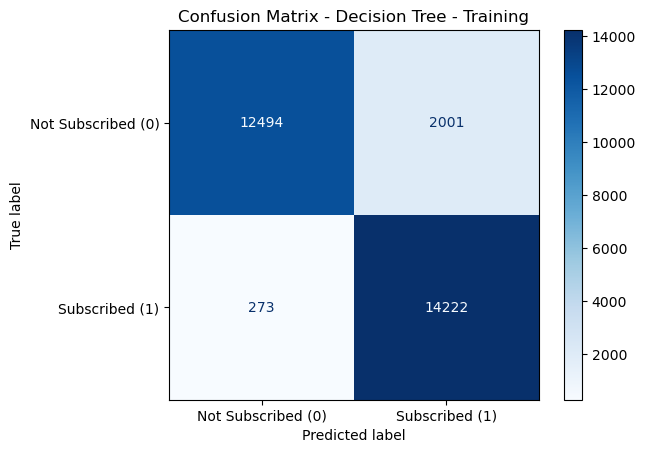

Test Classification Report: 
              precision    recall  f1-score   support

           0       0.98      0.84      0.91      3636
           1       0.44      0.86      0.59       526

    accuracy                           0.85      4162
   macro avg       0.71      0.85      0.75      4162
weighted avg       0.91      0.85      0.87      4162



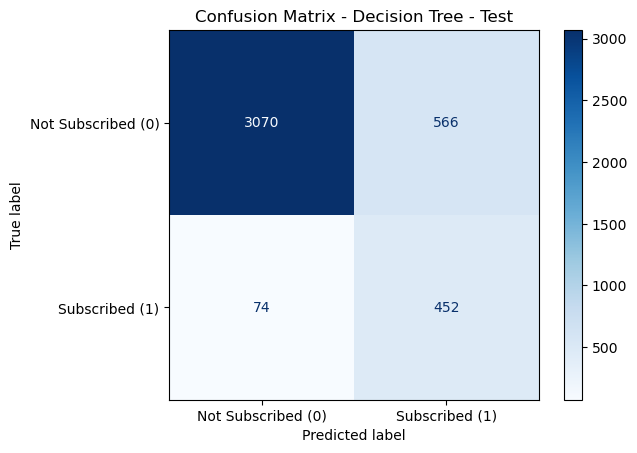

In [113]:
# Evaluation
# Training set performance
print("Training Classification Report: ")
print(classification_report(y_train, y_pred_train))
display_cm(y_train, y_pred_train, modelName="Decision Tree - Training")
# Testing set performance
print("Test Classification Report: ")
print(classification_report(y_test, y_pred_test))
display_cm(y_test, y_pred_test, modelName="Decision Tree - Test")

Unique classes: [0 1]


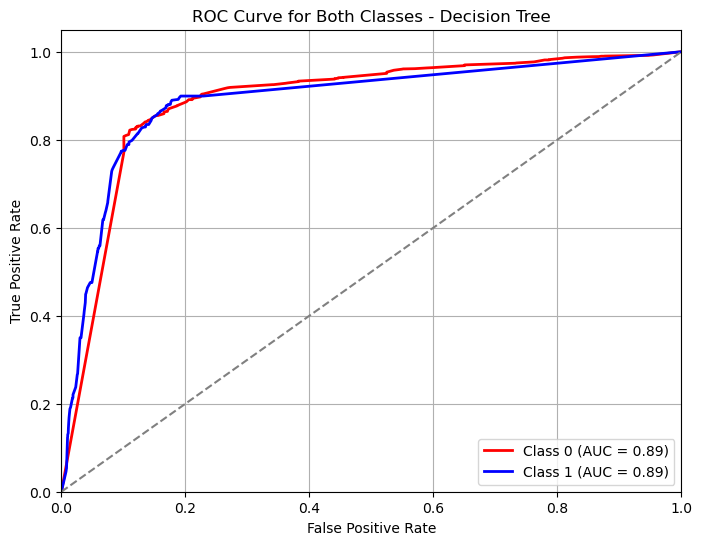

In [114]:
# For both classes
print("Unique classes:", np.unique(y_test))
plot_binary_roc_curve(best_dt_model, x_test, y_test, model_name="Decision Tree")

# KNN

In [115]:
from sklearn.neighbors import KNeighborsClassifier

# Construct classifier
knn_model = KNeighborsClassifier()

# Tune hyperparameters
param_grid = {'n_neighbors': range(3, 21)} #test from 3 to 20
grid_search = GridSearchCV(knn_model, param_grid, cv=5)
grid_search.fit(x_train, y_train)

# Get the best model from grid search
best_knn_model = grid_search.best_estimator_

# Predictions
y_pred_train = best_knn_model.predict(x_train)
y_pred_test = best_knn_model.predict(x_test)


Training Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.93      0.96     14495
           1       0.93      1.00      0.97     14495

    accuracy                           0.96     28990
   macro avg       0.97      0.96      0.96     28990
weighted avg       0.97      0.96      0.96     28990



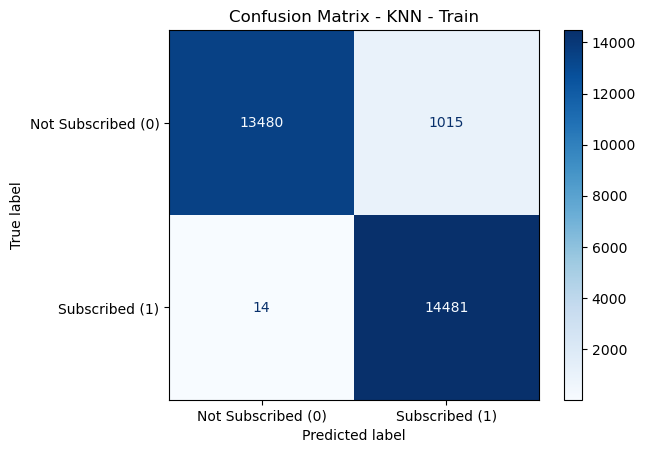

Test Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.88      0.91      3636
           1       0.43      0.63      0.51       526

    accuracy                           0.85      4162
   macro avg       0.68      0.75      0.71      4162
weighted avg       0.88      0.85      0.86      4162



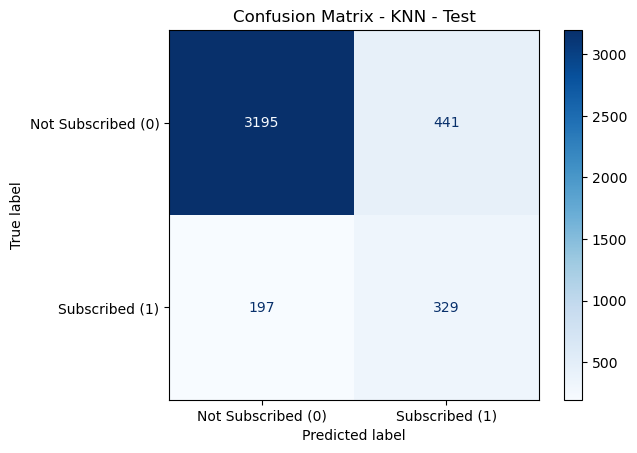

In [116]:
# Training set performance
print("Training Classification Report:")
print(classification_report(y_train, y_pred_train))
display_cm(y_train, y_pred_train, modelName="KNN - Train")
# Test set performance
print("Test Classification Report:")
print(classification_report(y_test, y_pred_test))
display_cm(y_test, y_pred_test, modelName="KNN - Test")

Unique classes: [0 1]


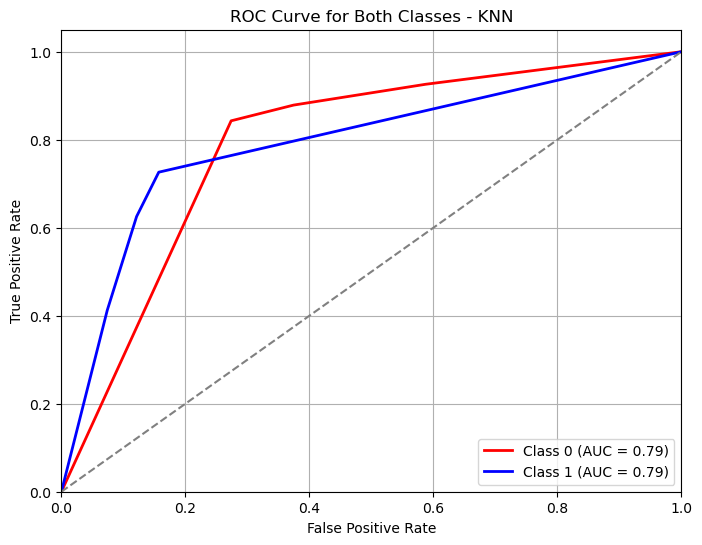

In [117]:
# For both classes
print("Unique classes:", np.unique(y_test))
plot_binary_roc_curve(best_knn_model, x_test, y_test, model_name="KNN")

# Random Forest

In [118]:
from sklearn.ensemble import RandomForestClassifier

# Initial model
rf_model = RandomForestClassifier(random_state=42)

# Tune hyperparameters
param_grid = {'n_estimators': [50, 100, 150],  'max_depth': [5, 10]}

# Tune hyperparameter
grid_search = GridSearchCV(rf_model, param_grid, cv=5)
grid_search.fit(x_train, y_train)

# Get the best model from the grid search
best_rf_model = grid_search.best_estimator_

# Make predictions using the best model
y_pred_train = best_rf_model.predict(x_train)
y_pred_test = best_rf_model.predict(x_test)

Training Classification Report: 
              precision    recall  f1-score   support

           0       0.97      0.88      0.92     14495
           1       0.89      0.97      0.93     14495

    accuracy                           0.93     28990
   macro avg       0.93      0.93      0.93     28990
weighted avg       0.93      0.93      0.93     28990



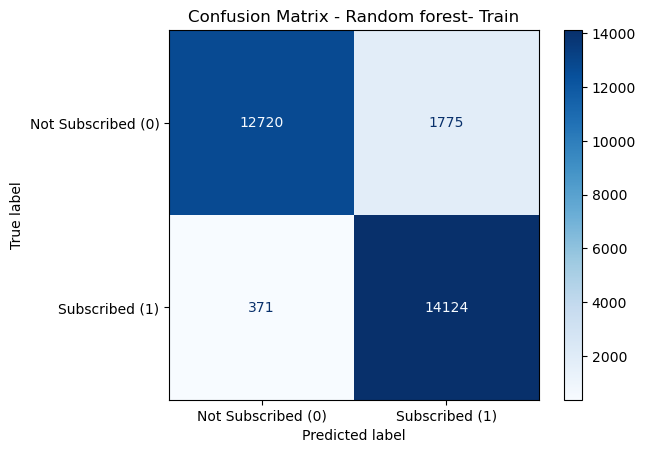

Test Classification Report: 
              precision    recall  f1-score   support

           0       0.98      0.86      0.91      3636
           1       0.47      0.87      0.61       526

    accuracy                           0.86      4162
   macro avg       0.72      0.87      0.76      4162
weighted avg       0.91      0.86      0.88      4162



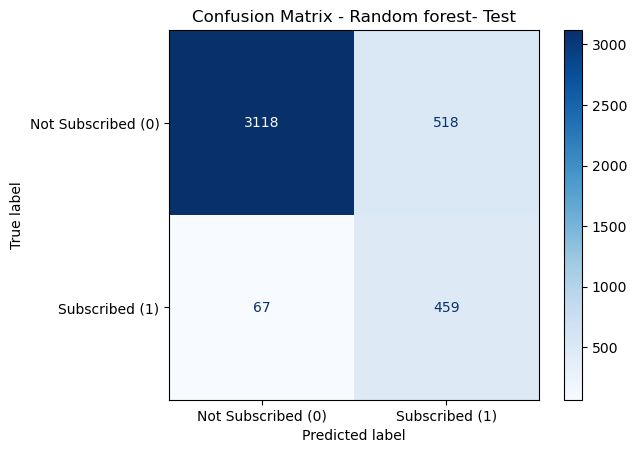

In [119]:
# Evaluation
# Training set performance
print("Training Classification Report: ")
print(classification_report(y_train, y_pred_train))
display_cm(y_train, y_pred_train, modelName="Random forest- Train")
# Testing set performance
print("Test Classification Report: ")
print(classification_report(y_test, y_pred_test))
display_cm(y_test, y_pred_test, modelName="Random forest- Test")

Unique classes: [0 1]


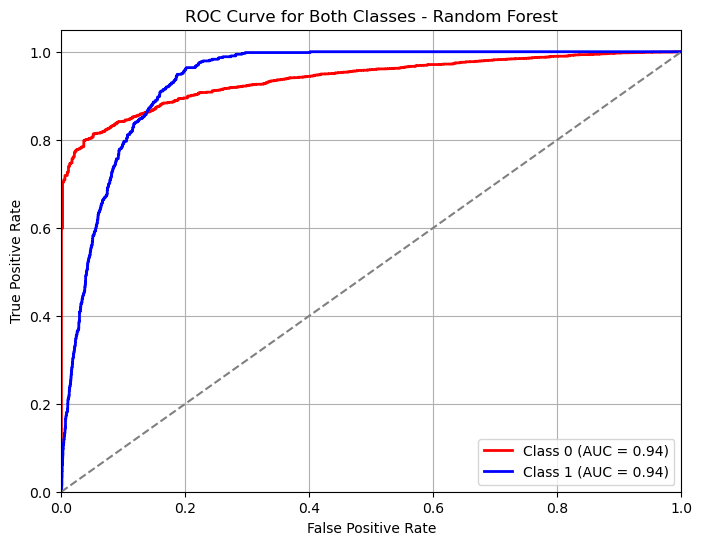

In [120]:
# For both classes
print("Unique classes:", np.unique(y_test))
plot_binary_roc_curve(best_rf_model, x_test, y_test, model_name="Random Forest")

# Adaboost classifier

In [121]:
from sklearn.ensemble import AdaBoostClassifier

# Initial model
ada_model = AdaBoostClassifier(random_state=42)

# Tune hyperparameters
param_grid = {'n_estimators': [10, 50, 100], 'learning_rate': [0.5, 1.0, 1.5]}

# Tune hyperparameter
grid_search = GridSearchCV(ada_model, param_grid, cv=5)
grid_search.fit(x_train, y_train)

# Get the best model from the grid search
best_ada_model = grid_search.best_estimator_

# Make predictions using the best model
y_pred_train = best_ada_model.predict(x_train)
y_pred_test = best_ada_model.predict(x_test)


Training Classification Report: 
              precision    recall  f1-score   support

           0       0.89      0.85      0.87     14495
           1       0.86      0.89      0.87     14495

    accuracy                           0.87     28990
   macro avg       0.87      0.87      0.87     28990
weighted avg       0.87      0.87      0.87     28990



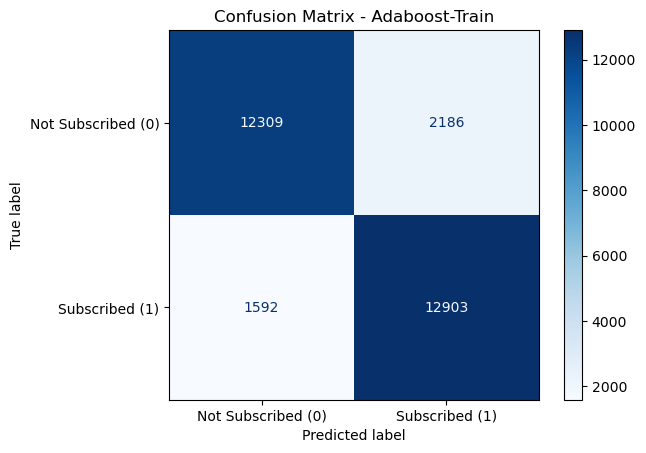

Test Classification Report: 
              precision    recall  f1-score   support

           0       0.98      0.85      0.91      3636
           1       0.46      0.90      0.61       526

    accuracy                           0.85      4162
   macro avg       0.72      0.87      0.76      4162
weighted avg       0.92      0.85      0.87      4162



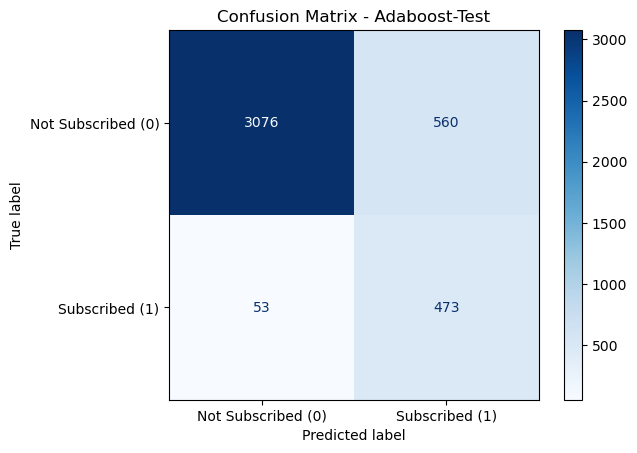

In [122]:
# Evaluation
# Training set performance
print("Training Classification Report: ")
print(classification_report(y_train, y_pred_train))
display_cm(y_train, y_pred_train, modelName="Adaboost-Train")
# Testing set performance
print("Test Classification Report: ")
print(classification_report(y_test, y_pred_test))
display_cm(y_test, y_pred_test, modelName="Adaboost-Test")

Unique classes: [0 1]


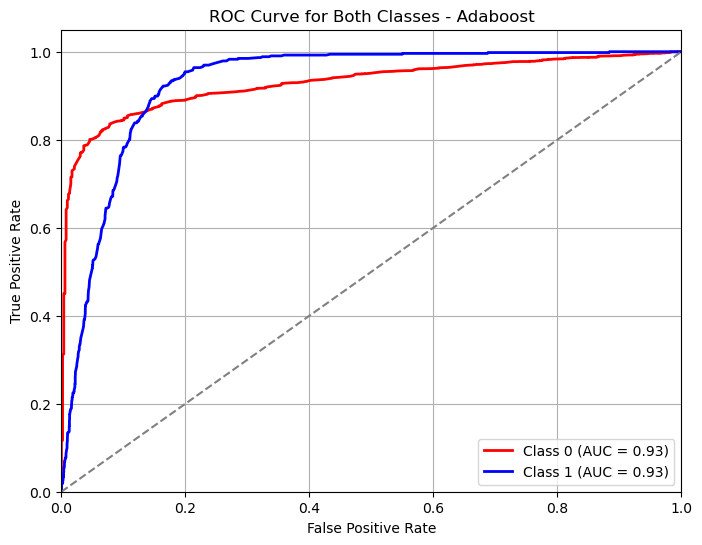

In [123]:
# For both classes
print("Unique classes:", np.unique(y_test))
plot_binary_roc_curve(best_ada_model, x_test, y_test, model_name="Adaboost") 

# Neutral network

In [124]:
from sklearn.neural_network import MLPClassifier

# Inspired from week 11 Python code 
nn_model = MLPClassifier(hidden_layer_sizes=(100, 50, 30, 20, 20), 
                    early_stopping=True,
                    validation_fraction=0.2,
                    verbose=True, 
                    )

# Tune hyperparameter inspired by McCaffery (2023)
param_grid = {
   'hidden_layer_sizes': [(100, 50, 30), (100, 50, 30, 20)], # try with more 
    'learning_rate_init': [0.001] 
    }
grid_search = GridSearchCV(nn_model, param_grid, cv=5)
grid_search.fit(x_train, y_train)

# Get the best model from grid search
best_nn_model = grid_search.best_estimator_

# Get the best parameters
print(f"Best Parameters: {grid_search.best_params_}")

# Make predictions using the best model
y_pred_train = best_nn_model.predict(x_train)
y_pred_test = best_nn_model.predict(x_test)


Iteration 1, loss = 0.59354629
Validation score: 0.721923
Iteration 2, loss = 0.52379141
Validation score: 0.756197
Iteration 3, loss = 0.46021118
Validation score: 0.817849
Iteration 4, loss = 0.39898796
Validation score: 0.838543
Iteration 5, loss = 0.37903128
Validation score: 0.819358
Iteration 6, loss = 0.36932248
Validation score: 0.845872
Iteration 7, loss = 0.36261638
Validation score: 0.845656
Iteration 8, loss = 0.35779259
Validation score: 0.844363
Iteration 9, loss = 0.35185414
Validation score: 0.846734
Iteration 10, loss = 0.34954207
Validation score: 0.846734
Iteration 11, loss = 0.34861820
Validation score: 0.843501
Iteration 12, loss = 0.34498028
Validation score: 0.850399
Iteration 13, loss = 0.34636902
Validation score: 0.849752
Iteration 14, loss = 0.33887525
Validation score: 0.849537
Iteration 15, loss = 0.33891603
Validation score: 0.853201
Iteration 16, loss = 0.33843693
Validation score: 0.843501
Iteration 17, loss = 0.33598769
Validation score: 0.853201
Iterat

Training Classification Report: 
              precision    recall  f1-score   support

           0       0.89      0.80      0.85     14495
           1       0.82      0.90      0.86     14495

    accuracy                           0.85     28990
   macro avg       0.86      0.85      0.85     28990
weighted avg       0.86      0.85      0.85     28990



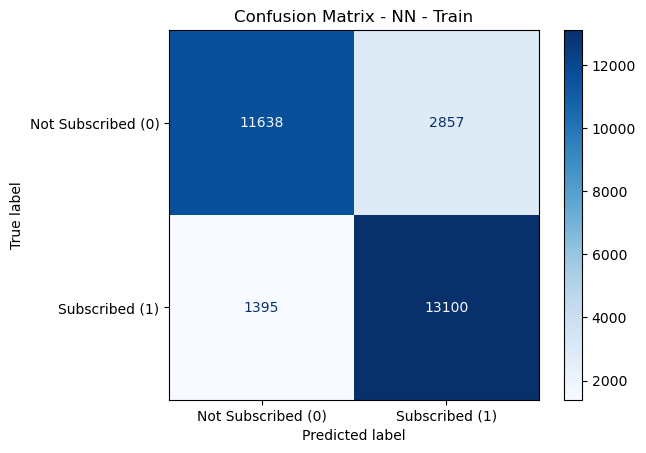

Test Classification Report: 
              precision    recall  f1-score   support

           0       0.99      0.80      0.89      3636
           1       0.40      0.92      0.56       526

    accuracy                           0.82      4162
   macro avg       0.70      0.86      0.72      4162
weighted avg       0.91      0.82      0.84      4162



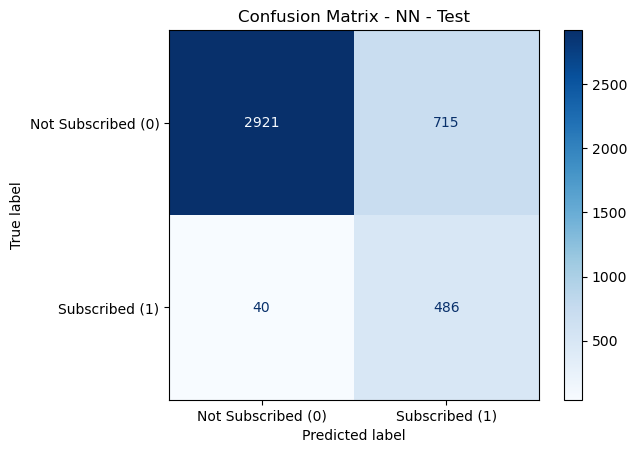

In [125]:
# Evaluation
print("Training Classification Report: ")
print(classification_report(y_train, y_pred_train))
display_cm(y_train, y_pred_train, modelName="NN - Train")
print("Test Classification Report: ")
print(classification_report(y_test, y_pred_test))
display_cm(y_test, y_pred_test, modelName="NN - Test")

Unique classes: [0 1]


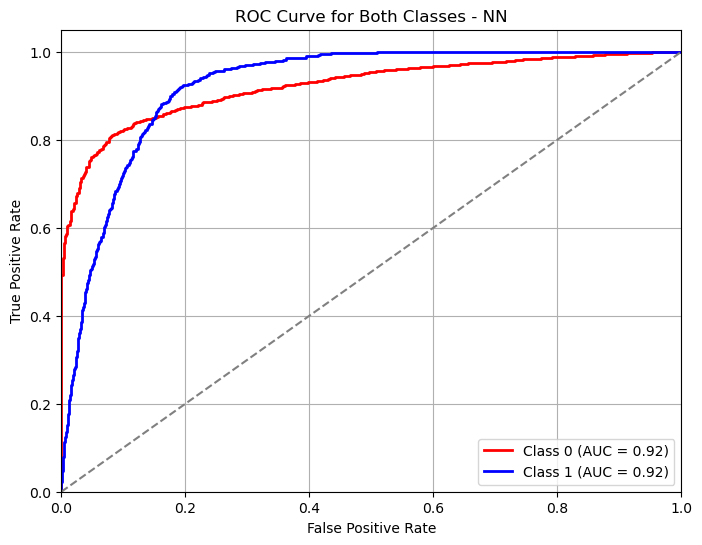

In [126]:
# For both classes
print("Unique classes:", np.unique(y_test))
plot_binary_roc_curve(best_nn_model, x_test, y_test, model_name="NN") 

# NuSVC

In [127]:
from sklearn.svm import NuSVC
# Initial model
nusvc_model = NuSVC(random_state=42)
# Tune hyperparameter -inspired from week 10 code
param_grid = {
     'nu': [0.1, 0.3, 0.5, 0.7],     
     'kernel': ['linear', 'rbf', 'poly', 'sigmoid'], 
     'gamma': ['scale', 'auto']           
 }
# grid_search = GridSearchCV(nusvc_model, param_grid, cv=5)
grid_search.fit(x_train, y_train)
# Get the best model from grid search
best_nusvc_model = grid_search.best_estimator_
# Get the best parameters
print(f"Best Parameters: {grid_search.best_params_}")
# Make predictions using the best model
y_pred_train = best_nusvc_model.predict(x_train)
y_pred_test = best_nusvc_model.predict(x_test)

Iteration 1, loss = 0.58971595
Validation score: 0.717180
Iteration 2, loss = 0.51759141
Validation score: 0.761155
Iteration 3, loss = 0.43414310
Validation score: 0.821944
Iteration 4, loss = 0.39408738
Validation score: 0.827118
Iteration 5, loss = 0.38129278
Validation score: 0.835740
Iteration 6, loss = 0.37395192
Validation score: 0.841345
Iteration 7, loss = 0.37142811
Validation score: 0.839621
Iteration 8, loss = 0.36620389
Validation score: 0.842854
Iteration 9, loss = 0.35975494
Validation score: 0.843716
Iteration 10, loss = 0.35516791
Validation score: 0.837896
Iteration 11, loss = 0.35412840
Validation score: 0.841992
Iteration 12, loss = 0.35046813
Validation score: 0.845656
Iteration 13, loss = 0.34642218
Validation score: 0.845872
Iteration 14, loss = 0.34756421
Validation score: 0.849752
Iteration 15, loss = 0.34767268
Validation score: 0.849105
Iteration 16, loss = 0.34242305
Validation score: 0.850614
Iteration 17, loss = 0.33933410
Validation score: 0.848459
Iterat

Training Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.80      0.86     14495
           1       0.83      0.93      0.88     14495

    accuracy                           0.87     28990
   macro avg       0.88      0.87      0.87     28990
weighted avg       0.88      0.87      0.87     28990



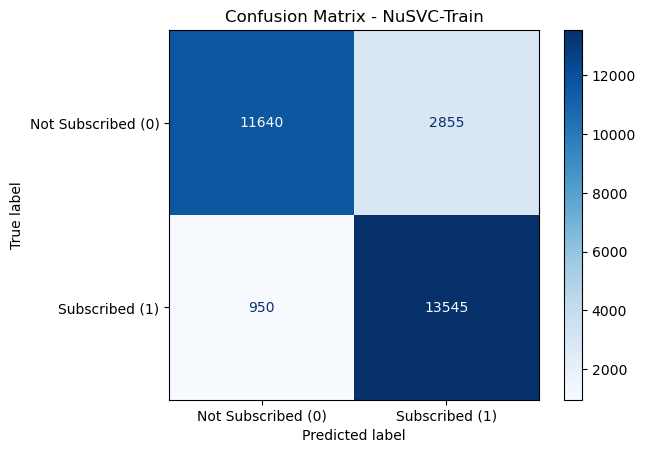

Test Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.80      0.88      3636
           1       0.40      0.92      0.56       526

    accuracy                           0.81      4162
   macro avg       0.69      0.86      0.72      4162
weighted avg       0.91      0.81      0.84      4162



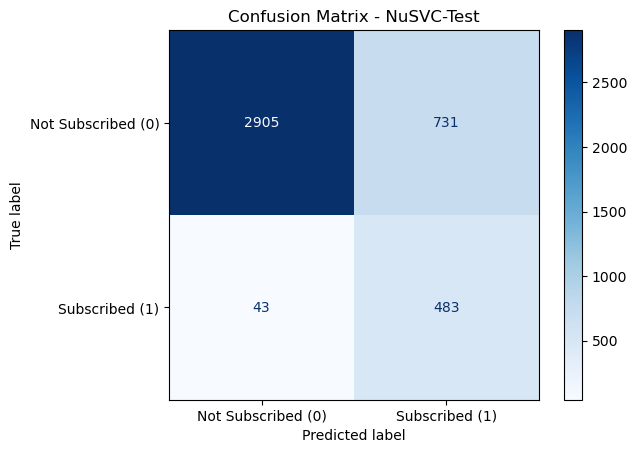

In [128]:
# Evaluation
print("Training Classification Report:")
print(classification_report(y_train, y_pred_train))
display_cm(y_train, y_pred_train, modelName="NuSVC-Train")

print("Test Classification Report:")
print(classification_report(y_test, y_pred_test))
display_cm(y_test, y_pred_test, modelName="NuSVC-Test")

Unique classes: [0 1]


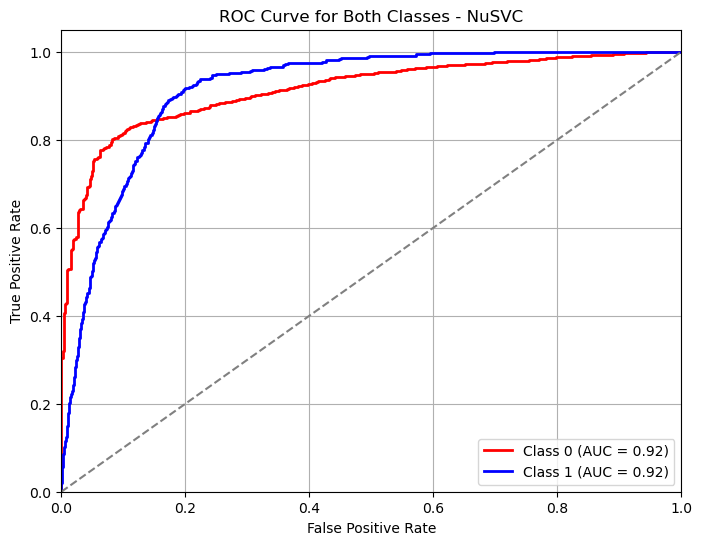

In [129]:
# For both classes
print("Unique classes:", np.unique(y_test))
plot_binary_roc_curve(best_nusvc_model, x_test, y_test, model_name="NuSVC")

# Save the model

In [130]:
# Load the model
import joblib

# Save model
joblib.dump(best_dt_model, 'dt_model.pkl')
joblib.dump(best_rf_model, 'rf_model.pkl')
joblib.dump(best_knn_model, 'knn_model.pkl')
joblib.dump(best_ada_model, 'ada_model.pkl')
joblib.dump(best_nn_model, 'nn_model.pkl')
joblib.dump(best_nusvc_model, 'nusvc_model.pkl')

#Verify
print("All saved")


All saved


References:
* Viewed and insipred from these sources and weekly Python code
- AnalyticsVidhya. (2021, May 19). How to Handle Missing Data in Python? [Explained in 5 Easy Steps]. Analytics Vidhya. https://www.analyticsvidhya.com/blog/2021/05/dealing-with-missing-values-in-python-a-complete-guide/
- W3Schools.com (2025). https://www.w3schools.com/python/pandas/ref_df_iterrows.asp
- W3Schools.com. (2025). https://www.w3schools.com/python/pandas/ref_df_fillna.asp
- Working with missing data — pandas 2.2.3 documentation. (2020). Pydata.org. https://pandas.pydata.org/docs/user_guide/missing_data.html
- MrMey. (2019, December 24). Stack Overflow. Stack Overflow. https://stackoverflow.com/questions/59465731/how-to-balance-training-set-in-python
- resample — SciPy v1.15.3 Manual. (2025). Scipy.org. https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.resample.html
- W3Schools.com. (2025). W3schools.com. https://www.w3schools.com/python/python_ml_cross_validation.asp
- Team, E. (2023, May 30). Hyperparameter Tuning with GridSearchCV. Great Learning Blog: Free Resources What Matters to Shape Your Career! https://www.mygreatlearning.com/blog/gridsearchcv/
- GeeksforGeeks. (2024, April 16). How to tune a Decision Tree in Hyperparameter tuning. GeeksforGeeks. https://www.geeksforgeeks.org/-how-to-tune-a-decision-tree-in-hyperparameter-tuning/
melihkanbay. (2020, February 7). KNN Best Parameters - GridSearchCV. Kaggle.com; Kaggle. https://www.kaggle.com/code/melihkanbay/knn-best-parameters-gridsearchcv
- Koehrsen, W. (2018, January 9). Hyperparameter Tuning the Random Forest in Python | Towards Data Science. Towards Data Science. https://towardsdatascience.com/hyperparameter-tuning-the-random-forest-in-python-using-scikit-learn-28d2aa77dd74/
- shubhamlipare. (2023, June 17). AdaBoost Tutorial with Hyperparameter Tuning. Kaggle.com; Kaggle. https://www.kaggle.com/code/shubhamlipare/adaboost-tutorial-with-hyperparameter-tuning
- rendyk. (2021, May 26). Tuning the Hyperparameters and Layers of Neural Network Deep Learning. Analytics Vidhya. https://www.analyticsvidhya.com/blog/2021/05 tuning-the-hyperparameters-and-layers-of-neural-network-deep-learning/
- McCaffery, J. (2023). Regression Using a scikit MLPRegressor Neural Network -- Visual Studio Magazine. Visual Studio Magazine. https://visualstudiomagazine.com/articles/2023/05/01/regression-scikit.aspx
- Bais, G. (2023, May 10). How to Save Trained Model in Python. Neptune.ai. https://neptune.ai/blog/saving-trained-model-in-python
- Joblib: running Python functions as pipeline jobs — joblib 1.5.0 documentation. (2021). Readthedocs.io. https://joblib.readthedocs.io/en/stable/
- GeeksforGeeks. (2023, February 3). Massively Speed up Processing using Joblib in Python. GeeksforGeeks. https://www.geeksforgeeks.org/massively-speed-up-processing-using-joblib-in-python/